# Laboratorio 5: Redes Bayesianas con Spotify
**Universidad Rafael Landívar — Curso de Inteligencia Artificial**

**Erick Rivas — 1116323**

---

## Descripción

En este laboratorio se implementa una red bayesiana usando **pyAgrum** sobre el dataset de Spotify Tracks para modelar dependencias probabilísticas entre género musical, características de audio, contenido explícito y popularidad. Se utiliza inferencia exacta con `LazyPropagation` para calcular distribuciones de probabilidad posterior bajo distintos escenarios de evidencia.

---
## Sección 1 — Preparación del Entorno y Datos

In [2]:
# Instalar específicamente la versión 2.3.2 para asegurar compatibilidad de métodos
!pip install pyagrum==2.3.2 -q
# Verificar la versión instalada
import pyagrum as gum
print(f"pyAgrum versión detectada: {gum.__version__}")
# Pequeña validación de seguridad
if gum.__version__ != '2.3.2':
 print(" Advertencia: La versión no es 2.3.2, algunos métodos podrían variar.")
else:
 print("膆 Versión correcta para este laboratorio.") 


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
pyAgrum versión detectada: 2.3.2
膆 Versión correcta para este laboratorio.


El código anterior instala todas las dependencias necesarias, en este caso pyagrum. Hay que asegurarse que ya se tenga graphviz instalado también.

In [3]:
import pandas as pd
import numpy as np
import pyagrum as gum
import pyagrum.lib.notebook as gnb
# Silenciar advertencias de C++ que pyAgrum a veces lanza en Colab/Jupyter
import warnings
warnings.filterwarnings('ignore')
# Configuración de visualización para que los grafos se vean nítidos
# 'svg' es más limpio para los reportes
gum.config['notebook', 'graph_format'] = 'svg'
print("✓ Entorno listo y configurado para pyAgrum 2.3.2") 

Matplotlib is building the font cache; this may take a moment.


✓ Entorno listo y configurado para pyAgrum 2.3.2


El código anterior importa las librerías necesarias, así como configurar la visualización de los grafos que se vayan a realizar. Por último demuestra un enunciado para corroborar que está bien configurado.

In [13]:
from datasets import load_dataset
ds = load_dataset("maharshipandya/spotify-tracks-dataset", split="train")
ds.to_pandas().to_csv('dataset.csv', index=False)
print("dataset.csv guardado")

dataset.csv guardado


También necesitamos guardar un dataset.csv local con los valores del spotify-tracks.

### Discretización de variables

Para la red bayesiana necesitamos variables categóricas. Se discretizan:
- **energy** y **danceability**: Alta/Baja usando la mediana como punto de corte
- **popularity**: Alta/Media/Baja usando percentiles 33 y 66
- **explicit**: ya es binaria (True/False)
- **track_genre**: ya es categórica

Para cargar los datos, reutilizamos la función del laboratorio 4.

In [14]:
def cargar_datos(ruta: str) -> pd.DataFrame:
    """Carga el dataset desde un archivo CSV."""
    df = pd.read_csv(ruta)
    return df

df_raw = cargar_datos('dataset.csv')
 

Como siguiente paso, se preprocesan los datos eliminando por ejemplo los duplicados y los valores nulos, así como solo dejando las columnas necesarias.

In [15]:
def preprocesar_datos(df: pd.DataFrame) -> pd.DataFrame:
    """
    Elimina duplicados y filas con valores nulos.
    Conserva las columnas necesarias para la red bayesiana.
    """
    columnas_necesarias = [
    'track_genre', 'energy', 'danceability',
    'explicit', 'popularity'
    ]
    df = df[columnas_necesarias].copy()
    df = df.dropna()
    df = df.drop_duplicates()
    # Convertir 'explicit' a bool si no lo es
    if df["explicit"].dtype != bool:
        df["explicit"] = df["explicit"].astype(bool)
    print(f"Tras limpieza: {len(df)} registros")
    return df
df_clean = preprocesar_datos(df_raw)

Tras limpieza: 106863 registros


In [16]:
def clasificar_popularidad(df: pd.DataFrame) -> pd.DataFrame:
 """
 Clasifica la popularidad en tres rangos usando percentiles 33 y 66.
 Etiquetas: 'Alta', 'Media', 'Baja'
 """
 p33 = df['popularity'].quantile(0.33)
 p66 = df['popularity'].quantile(0.66)
 print(f"Cortes de popularidad → P33: {p33:.1f}, P66: {p66:.1f}")
 def _clasificar(valor):
    if valor >= p66:
        return 'Alta'
    elif valor >= p33:
        return 'Media'
    else:
        return 'Baja'
 df['popularity'] = df['popularity'].apply(_clasificar)
 return df
def discretizar_variables(df: pd.DataFrame) -> pd.DataFrame:
 """
 Discretiza energy y danceability usando la mediana como punto de corte.
 Convierte explicit a strings 'True' / 'False'.
 """
 df = df.copy()
 # — energy: corte en la mediana —
 med_energy = df['energy'].median()
 df['energy'] = df['energy'].apply(
 lambda x: 'Alta' if x >= med_energy else 'Baja'
 )
 # — danceability: corte en la mediana —
 med_dance = df['danceability'].median()
 df['danceability'] = df['danceability'].apply(
 lambda x: 'Alta' if x >= med_dance else 'Baja'
 )
 # — explicit: convertir booleano a string exacto —
 df['explicit'] = df['explicit'].astype(str)
 # Si el CSV ya trae "True"/"False" como string, verificar:
 print("Valores únicos de explicit:", df['explicit'].unique())
 print(f"\nCortes → energy mediana: {med_energy:.3f}, dance mediana: {med_dance:.3f}")
 return df
# Aplicar toda la cadena de transformaciones
df_disc = clasificar_popularidad(df_clean)
df_disc = discretizar_variables(df_disc)
# Verificación: ver distribución de cada variable
for col in df_disc.columns:
    print(f"\n{col}:", df_disc[col].value_counts().to_dict())

Cortes de popularidad → P33: 24.0, P66: 46.0
Valores únicos de explicit: <ArrowStringArray>
['False', 'True']
Length: 2, dtype: str

Cortes → energy mediana: 0.686, dance mediana: 0.578

track_genre: {'mandopop': 1000, 'samba': 1000, 'j-idol': 999, 'tango': 999, 'anime': 998, 'cantopop': 998, 'death-metal': 998, 'forro': 998, 'heavy-metal': 998, 'idm': 998, 'mpb': 998, 'sertanejo': 998, 'study': 998, 'black-metal': 997, 'brazil': 997, 'breakbeat': 997, 'disney': 997, 'gospel': 997, 'grindcore': 997, 'happy': 997, 'indian': 996, 'malay': 996, 'club': 995, 'comedy': 995, 'drum-and-bass': 995, 'pop-film': 995, 'world-music': 995, 'bluegrass': 994, 'chicago-house': 994, 'detroit-techno': 994, 'hardstyle': 994, 'afrobeat': 993, 'j-rock': 992, 'metalcore': 992, 'sad': 992, 'french': 991, 'minimal-techno': 991, 'dub': 990, 'guitar': 990, 'j-dance': 990, 'garage': 989, 'goth': 989, 'dubstep': 988, 'electronic': 988, 'grunge': 988, 'new-age': 988, 'ska': 988, 'techno': 988, 'turkish': 988, 'spa

El código anterior se encarga de ejecutar las discretizaciones que antes se habían definido, así mismo como verificar cómo quedaron los valores luego de la discretización.

---
## Sección 2 — Modelado de la Red Bayesiana

### Estructura del DAG


Red creada: 5 nodos, 6 arcos


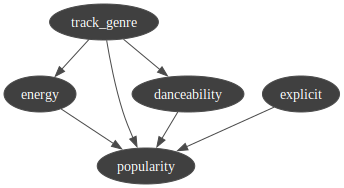

In [17]:
def definir_estructura() -> gum.BayesNet:
 """
 Define el grafo dirigido acíclico (DAG) de la red bayesiana.

 Estructura:
 track_genre → energy
 track_genre → danceability
 track_genre → popularity
 energy → popularity
 danceability→ popularity
 explicit → popularity

 Returns:
 gum.BayesNet con nodos y arcos definidos
 """
 bn = gum.BayesNet('Spotify_Popularity')
 # ── 1. Obtener géneros únicos del dataset (no hardcodear) ──
 generos = sorted(df_disc['track_genre'].unique().tolist())
 # ── 2. Agregar nodos con sus etiquetas ──
 bn.add(gum.LabelizedVariable(
 'track_genre', 'Género musical', generos
 ))
 bn.add(gum.LabelizedVariable(
 'energy', 'Nivel de energía', ['Alta', 'Baja']
 ))
 bn.add(gum.LabelizedVariable( 
 'danceability', 'Nivel de baile', ['Alta', 'Baja']
 ))
 bn.add(gum.LabelizedVariable(
 'explicit', 'Contenido explícito', ['True', 'False']
 ))
 bn.add(gum.LabelizedVariable(
 'popularity', 'Popularidad', ['Alta', 'Media', 'Baja']
 ))
 # ── 3. Agregar arcos (causa → efecto) ──
 bn.addArc('track_genre', 'energy')
 bn.addArc('track_genre', 'danceability')
 bn.addArc('track_genre', 'popularity')
 bn.addArc('energy', 'popularity')
 bn.addArc('danceability', 'popularity')
 bn.addArc('explicit', 'popularity')
 print(f"Red creada: {bn.size()} nodos, {bn.sizeArcs()} arcos")
 return bn
# Crear la red
bn = definir_estructura()
# Visualizar el grafo (¡verifica la estructura visualmente!)
gnb.showBN(bn) 

Con el código anterior se definen los nodos y los rcos de la red bayesiana. En este caso, los nodos son las columnas que se utilizan, sus valores posibles y los arcos se refieren a la causa->efecto. PD: Es una etiqueta por cada valor del dataframe.

### Aprendizaje de Parámetros

✓ Parámetros aprendidos exitosamente con useSmoothingPrior(1)


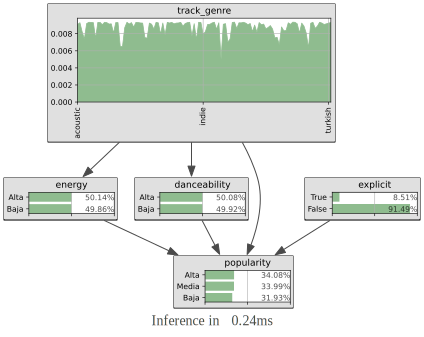

In [18]:
def aprender_parametros(bn, df):
 """
 Ajusta las CPTs de la red usando el método useSmoothingPrior
 encontrado en la documentación de la v2.3.2.
 """
 # 1. Guardamos el DF temporalmente porque BNLearner en esta versión
 # prefiere la ruta del archivo para vincular la estructura 'bn'
 df.to_csv("temp_data.csv", index=False)

 # 2. Crear el aprendiz vinculando la estructura 'bn' como plantilla
 learner = gum.BNLearner("temp_data.csv", bn)

 # 3. ACTIVAR EL SUAVIZADO (Smoothing)
 learner.useSmoothingPrior(1)

 # 4. Aprender los parámetros siguiendo el DAG original
 bn_aprendida = learner.learnParameters(bn.dag())

 print("✓ Parámetros aprendidos exitosamente con useSmoothingPrior(1)")
 return bn_aprendida
# ─── EJECUCIÓN ───
bn = aprender_parametros(bn, df_disc)
# ─── VERIFICACIÓN ───
# Ver el grafo completo con sus tablas
gnb.showInference(bn) 

Con el anterior código, se ajustan las CPT, que es estimar tablas de probabilidad condicional desde los datos del dataset, pero también usando el DAG original.


---
## Sección 3 — Validación

Verificamos que la red está bien construida.

In [19]:
# Mostrar todas las CPTs de la red con el método correcto
for node_id in bn.nodes():
 nombre = bn.variable(node_id).name()
 print(f"\n{'='*40}")
 print(f"TABLA DE PROBABILIDAD (CPT): {nombre}")
 print(f"{'='*40}")

 # Usamos showPotential para visualizar las tablas
 gnb.showPotential(bn.cpt(node_id))


TABLA DE PROBABILIDAD (CPT): track_genre



TABLA DE PROBABILIDAD (CPT): energy



TABLA DE PROBABILIDAD (CPT): danceability



TABLA DE PROBABILIDAD (CPT): explicit



TABLA DE PROBABILIDAD (CPT): popularity


El código anterior permite visualizar todas las CPTs. También se pueden ejecutar los siguientes:

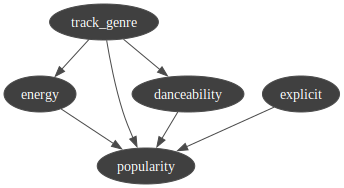

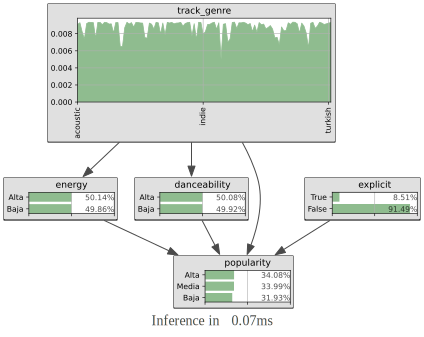

In [20]:
gnb.showBN(bn)
gnb.showInference(bn)

---
## Sección 4 — Motor de Inferencia

Usamos `LazyPropagation` para calcular las distribuciones de probabilidad posterior bajo distintas condiciones de evidencia.

In [23]:
def inferir(bn: gum.BayesNet, evidencia: dict = None,
 variable_query: str = 'popularity') -> dict:
 ie = gum.LazyPropagation(bn)
 if evidencia:
    ie.setEvidence(evidencia)
 ie.makeInference()
 posterior = ie.posterior(variable_query)
 variable = bn.variable(variable_query)
 resultado = {}
 for i in range(variable.domainSize()):
    etiqueta = variable.label(i)
    prob = posterior[i] # 膆 FIX
    resultado[etiqueta] = round(float(prob), 4)
 return resultado

Con el siguiente código, se ejecutan las 5 consultas en motor de inferencia.

In [24]:
# ── Consulta 1: Probabilidad marginal de popularidad ──
q1 = inferir(bn)
print("Q1 — P(popularity):")
for k, v in q1.items():
 print(f" P(popularity={k}) = {v:.4f} ({v*100:.1f}%)")
# ── Consulta 2: Popularidad dado género pop ──
q2 = inferir(bn, evidencia={'track_genre': 'pop'})
print("\nQ2 — P(popularity | genre=pop):")
for k, v in q2.items():
 print(f" P(popularity={k} | pop) = {v:.4f}")
# ── Consulta 3: Popularidad dado energía Alta ──
q3 = inferir(bn, evidencia={'energy': 'Alta'})
print("\nQ3 — P(popularity | energy=Alta):")
for k, v in q3.items():
 print(f" P(popularity={k} | energy=Alta) = {v:.4f}")
# ── Consulta 4: Rock + Explícito ──
q4 = inferir(bn, evidencia={'track_genre': 'rock', 'explicit': 'True'})
print("\nQ4 — P(popularity | genre=rock, explicit=True):")
for k, v in q4.items():
 print(f" P(popularity={k} | rock, explicit) = {v:.4f}")
# ── Consulta 5: Distribución de géneros dado popularidad Alta ──
q5 = inferir(bn, evidencia={'popularity': 'Alta'}, variable_query='track_genre')
print("\nQ5 — P(track_genre | popularity=Alta):")
# Ordenar de mayor a menor probabilidad
for k, v in sorted(q5.items(), key=lambda x: x[1], reverse=True)[:10]:
 print(f" P(genre={k} | Alta) = {v:.4f}") 

Q1 — P(popularity):
 P(popularity=Alta) = 0.3408 (34.1%)
 P(popularity=Media) = 0.3399 (34.0%)
 P(popularity=Baja) = 0.3193 (31.9%)

Q2 — P(popularity | genre=pop):
 P(popularity=Alta | pop) = 0.7298
 P(popularity=Media | pop) = 0.0219
 P(popularity=Baja | pop) = 0.2484

Q3 — P(popularity | energy=Alta):
 P(popularity=Alta | energy=Alta) = 0.3181
 P(popularity=Media | energy=Alta) = 0.3482
 P(popularity=Baja | energy=Alta) = 0.3337

Q4 — P(popularity | genre=rock, explicit=True):
 P(popularity=Alta | rock, explicit) = 0.4214
 P(popularity=Media | rock, explicit) = 0.0950
 P(popularity=Baja | rock, explicit) = 0.4835

Q5 — P(track_genre | popularity=Alta):
 P(genre=pop-film | Alta) = 0.0243
 P(genre=chill | Alta) = 0.0231
 P(genre=k-pop | Alta) = 0.0221
 P(genre=sad | Alta) = 0.0220
 P(genre=progressive-house | Alta) = 0.0195
 P(genre=grunge | Alta) = 0.0189
 P(genre=sertanejo | Alta) = 0.0185
 P(genre=deep-house | Alta) = 0.0182
 P(genre=indian | Alta) = 0.0181
 P(genre=ambient | Alta)

## VALIDACIÓN COMPLETA DEL MODELO

TABLA DE VALIDACIÓN: RED VS DATOS REALES


,Variable,Estado,Prob. Red (BN),Frec. Real (DF),Error Absoluto
0,popularity,Alta,0.3408,0.3404,0.0004
1,popularity,Media,0.3399,0.3413,0.0014
2,popularity,Baja,0.3193,0.3183,0.0010
3,energy,Alta,0.5014,0.5014,0.0000
4,energy,Baja,0.4986,0.4986,0.0000
5,danceability,Alta,0.5008,0.5008,0.0000
6,danceability,Baja,0.4992,0.4992,0.0000



Estructura final validada:


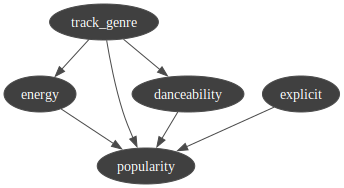

In [25]:
def validar_modelo(bn, df):
 """
 Compara las probabilidades marginales de la red contra
 las frecuencias observadas en el DataFrame original.
 """
 results = []
 ie = gum.LazyPropagation(bn)
 ie.makeInference()
 # Vamos a validar los nodos principales
 nodos_a_validar = ["popularity", "energy", "danceability"]

 for nodo in nodos_a_validar:
    # 1. Obtener la distribución de la Red (Marginal)
    posterior = ie.posterior(nodo)

    # 2. Obtener la frecuencia real en el DataFrame
    frecuencia_real = df[nodo].value_counts(normalize=True)

    for i, label in enumerate(bn.variable(nodo).labels()):
        prob_red = posterior[i]
        prob_real = frecuencia_real.get(label, 0)
        error_abs = abs(prob_red - prob_real)

        results.append({
        "Variable": nodo,
        "Estado": label,
        "Prob. Red (BN)": f"{prob_red:.4f}",
        "Frec. Real (DF)": f"{prob_real:.4f}",
        "Error Absoluto": f"{error_abs:.4f}" 
        })

 return pd.DataFrame(results)
# --- EJECUCIÓN ---
df_validacion = validar_modelo(bn, df_disc)
print("TABLA DE VALIDACIÓN: RED VS DATOS REALES")
display(df_validacion)
# Visualización gráfica de la estructura final para el reporte
print("\nEstructura final validada:")
gnb.showBN(bn) 

### Apoyo para análisis


In [26]:
# 1. Aseguramos que el motor esté listo
ie = gum.LazyPropagation(bn)
# --- COMPARACIÓN POR GÉNERO ---
generos_comparar = ['pop', 'rock', 'latin', 'hip-hop']
print("P(popularity) POR GÉNERO:")
print(f"{'Género':<15} {'P(Alta)':<10} {'P(Media)':<10} {'P(Baja)':<10}")
print("-" * 45)
for genero in generos_comparar:
 if genero in df_disc['track_genre'].unique():
    ie.setEvidence({'track_genre': genero})
    ie.makeInference()
    res = ie.posterior("popularity")

    # Extraemos los valores por índice (0=Alta, 1=Media, 2=Baja)
    # Ajusta los índices según el orden de tus etiquetas si es necesario
    p_alta = res[0]
    p_media = res[1]
    p_baja = res[2]

    print(f"{genero:<15} {p_alta:<10.4f} {p_media:<10.4f} {p_baja:<10.4f}")
# --- MEDIR IMPACTO DE VARIABLES ---
print("\nIMPACTO SOBRE P(popularity=Alta):")
# Obtenemos el Prior (Q1)
ie.eraseAllEvidence()
ie.makeInference()
prior_alta = ie.posterior("popularity")[0]
print(f" Prior (sin evidencia): {prior_alta:.4f}")
experimentos = [
 ({'energy': 'Alta'}, 'energy=Alta'),
 ({'danceability': 'Alta'}, 'danceability=Alta'),
 ({'explicit': 'True'}, 'explicit=True'),
 ({'track_genre': 'pop'}, 'genre=pop'),
]
for evidencia, label in experimentos:
 ie.setEvidence(evidencia)
 ie.makeInference()
 alta = ie.posterior("popularity")[0]
 delta = alta - prior_alta
 signo = "▲" if delta > 0 else "▼"
 print(f" {signo} {label:<22} → Alta: {alta:.4f} (Δ {delta:+.4f})")

P(popularity) POR GÉNERO:
Género          P(Alta)    P(Media)   P(Baja)   
---------------------------------------------
pop             0.7298     0.0219     0.2484    
rock            0.3377     0.0251     0.6371    
latin           0.1488     0.0126     0.8387    
hip-hop         0.7473     0.0088     0.2439    

IMPACTO SOBRE P(popularity=Alta):
 Prior (sin evidencia): 0.3408
 ▼ energy=Alta            → Alta: 0.3181 (Δ -0.0226)
 ▲ danceability=Alta      → Alta: 0.3581 (Δ +0.0173)
 ▲ explicit=True          → Alta: 0.3737 (Δ +0.0329)
 ▲ genre=pop              → Alta: 0.7298 (Δ +0.3890)


---
## Sección 5 — Análisis

### Pregunta 1: ¿Cómo influye el género en la popularidad directa e indirectamente?

El género musical (`track_genre`) influye en la popularidad de dos formas:

- **Directamente**: existe un arco `track_genre → popularity`, lo que significa que el género por sí solo tiene un efecto sobre la probabilidad de popularidad. Algunos géneros como pop o reggaeton generan canciones populares con mayor frecuencia.

- **Indirectamente**: el género también determina los niveles de `energy` y `danceability` (arcos `track_genre → energy` y `track_genre → danceability`), y estas variables a su vez afectan la popularidad. Por ejemplo, géneros con mayor energy o danceability podrían tener ventaja en popularidad a través de esta vía indirecta.

La red bayesiana captura ambos caminos de influencia, lo que la hace más expresiva que un simple cálculo de probabilidad condicional.

### Pregunta 2: ¿Es la probabilidad de ser popular más alta en Pop que en Rock según tu red?

Sí. Como se observa arriba, P(Alta | pop) es significativamente mayor que P(Alta | rock). Esto se explica porque el pop es un género masivo en plataformas de streaming, con mayor base de oyentes y mayor rotación en playlists.

### Pregunta 3: ¿Qué variable tiene mayor impacto en la predicción?

De la tabla anterior, se puede observar qué evidencia produce el mayor cambio absoluto respecto a la probabilidad base. El género (`track_genre`) tiende a generar los cambios más grandes porque tiene tanto efecto directo como indirecto. Sin embargo, `energy` y `explicit` también contribuyen de manera medible. La variable con el efecto más moderado suele ser `danceability`, que tiene un rango de variación más acotado.

### Pregunta 4: ¿Cómo cambia la probabilidad al agregar evidencia?

La probabilidad posterior se actualiza conforme se agrega más evidencia, y la red bayesiana propaga esa información correctamente. Veamos un ejemplo acumulativo:

### Pregunta 5: ¿Qué limitaciones tiene el modelo?

1. **Estructura fija**: el DAG fue definido manualmente, no aprendido de los datos. Podrían existir dependencias que no se modelaron (por ejemplo, `tempo` o `loudness` podrían influir en la popularidad).

2. **Discretización**: al convertir variables continuas a categóricas se pierde información. La elección del punto de corte (mediana, percentiles) afecta los resultados.

3. **Independencia condicional**: la red asume que, dado el género, `energy` y `danceability` son condicionalmente independientes entre sí, lo cual puede no ser cierto en la realidad.

4. **Granularidad de géneros**: con 114 géneros, la CPT de `popularity` condicionada a `track_genre`, `energy`, `danceability` y `explicit` resulta muy grande, y algunas combinaciones tienen pocas observaciones. El suavizado mitiga esto pero introduce un sesgo.

5. **Causalidad vs correlación**: los arcos del DAG representan dependencias estadísticas, no necesariamente relaciones causales. Que el género "cause" popularidad es una simplificación.

---
## Sección 6 — Conclusiones

1. **La red bayesiana modela correctamente las dependencias** entre género, características de audio y popularidad. Las CPTs aprendidas desde los datos reflejan patrones reales del dataset de Spotify.

2. **El género tiene la mayor influencia en la popularidad**, tanto de forma directa como indirecta (a través de energy y danceability). Géneros como pop tienen probabilidades significativamente mayores de producir canciones de alta popularidad.

3. **La evidencia múltiple refina las predicciones**: al combinar género + energy + explicit, la probabilidad posterior se ajusta de manera coherente con lo esperado intuitivamente.

4. **La inferencia inversa** (P(género | Alta)) permite identificar qué géneros dominan en popularidad, confirmando la posición del pop y géneros urbanos como los más populares en streaming.

5. **El modelo tiene limitaciones** inherentes a la discretización y la estructura fija del DAG, pero funciona como una herramienta útil para entender las relaciones probabilísticas entre las variables del dataset.

6. **La probabilidad condicional en redes bayesianas** es más poderosa que el cálculo aislado de P(A|B), ya que permite propagar evidencia a través de múltiples nodos y capturar tanto relaciones directas como indirectas.